1. Write a python program from scratch to realize the k-means algorithm using
a. Random data points without outliers
b. Random data points with outliers
c. Some tabular data from kaggle
d. Image data where cluster interms of pixel pairs.


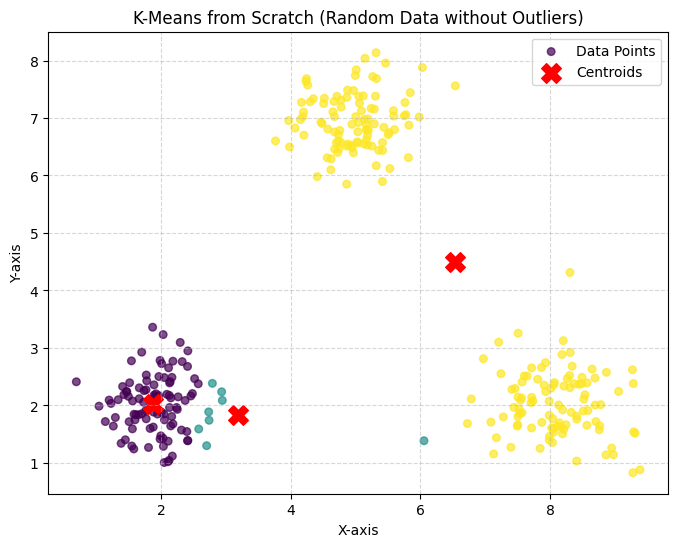

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. K-Means implementation from scratch
class KMeansScratch:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None

    def fit(self, X):
        # Randomly initialize centroids from the data points
        n_samples = X.shape[0]
        random_idx = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            # Assign clusters based on closest centroid (Euclidean distance)
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            # Calculate new centroids
            new_centroids = np.array([X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else self.centroids[i] for i in range(self.k)])

            # Check for convergence
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break
            self.centroids = new_centroids

        return labels, self.centroids

# 2. Generate random data points without outliers
np.random.seed(42)
# Generate 3 distinct clusters
cluster1 = np.random.normal(loc=[2, 2], scale=0.5, size=(100, 2))
cluster2 = np.random.normal(loc=[8, 2], scale=0.6, size=(100, 2))
cluster3 = np.random.normal(loc=[5, 7], scale=0.5, size=(100, 2))
X_no_outliers = np.vstack([cluster1, cluster2, cluster3])

# 3. Fit K-Means
kmeans = KMeansScratch(k=3)
labels, centroids = kmeans.fit(X_no_outliers)

# 4. Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(X_no_outliers[:, 0], X_no_outliers[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7, label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means from Scratch (Random Data without Outliers)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Part 1.b: K-Means with Outliers
We will now generate the same three distinct clusters, but inject a few extreme outliers to see how they affect centroid calculation and cluster boundaries.

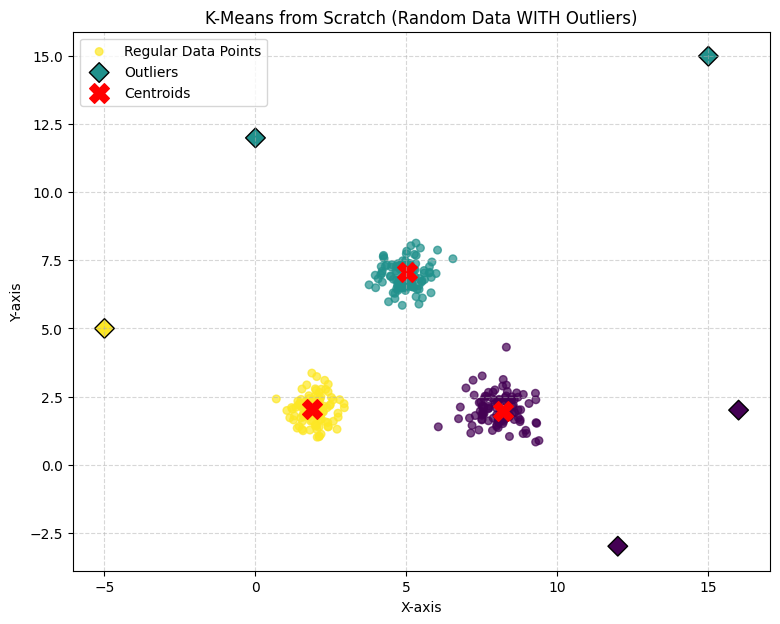

In [ ]:
# 1. Generate random data points with outliers
np.random.seed(42)
cluster1 = np.random.normal(loc=[2, 2], scale=0.5, size=(100, 2))
cluster2 = np.random.normal(loc=[8, 2], scale=0.6, size=(100, 2))
cluster3 = np.random.normal(loc=[5, 7], scale=0.5, size=(100, 2))

# Inject 5 extreme outliers
outliers = np.array([
    [15, 15],
    [16, 2],
    [-5, 5],
    [0, 12],
    [12, -3]
])

X_with_outliers = np.vstack([cluster1, cluster2, cluster3, outliers])

# 2. Fit K-Means on the dataset containing outliers
kmeans_outliers = KMeansScratch(k=3)
labels_outliers, centroids_outliers = kmeans_outliers.fit(X_with_outliers)

# 3. Plotting the results
plt.figure(figsize=(9, 7))
plt.scatter(X_with_outliers[:-5, 0], X_with_outliers[:-5, 1], c=labels_outliers[:-5], cmap='viridis', s=30, alpha=0.7, label='Regular Data Points')
plt.scatter(X_with_outliers[-5:, 0], X_with_outliers[-5:, 1], c=labels_outliers[-5:], cmap='viridis', marker='D', s=100, edgecolors='black', label='Outliers')
plt.scatter(centroids_outliers[:, 0], centroids_outliers[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title('K-Means from Scratch (Random Data WITH Outliers)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Part 1.c: K-Means on Tabular Data
We will read California Housing tabular dataset, scale the spatial features (`longitude` and `latitude`), and group them into 5 distinct geographic regions using our custom K-Means implementation.

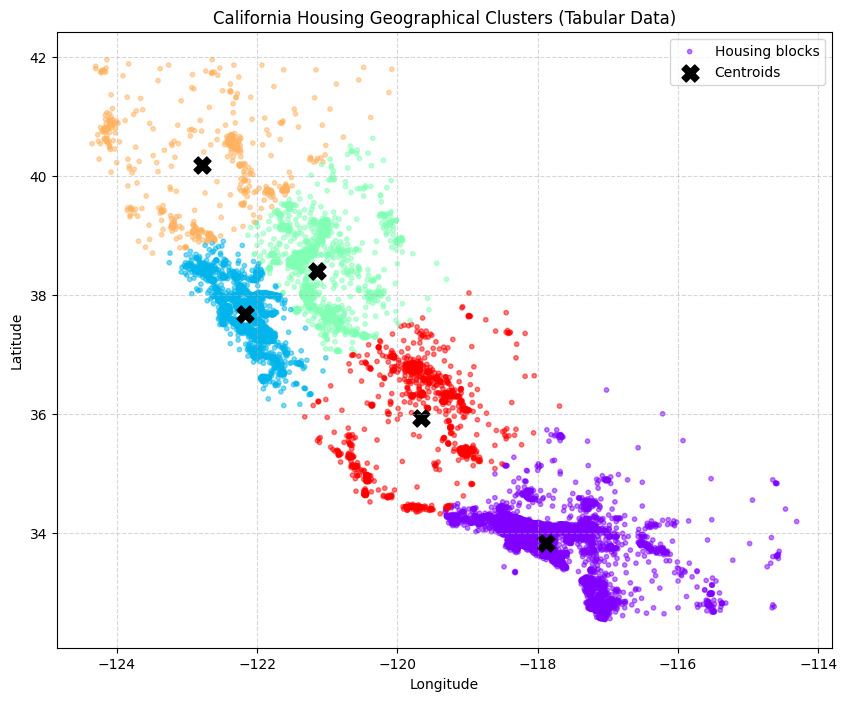

In [ ]:
import pandas as pd

# 1. Load the tabular dataset
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Select features for clustering (Longitude & Latitude)
X_tabular = df[['longitude', 'latitude']].values

# Standardize features for optimal K-Means performance
X_mean = X_tabular.mean(axis=0)
X_std = X_tabular.std(axis=0)
X_scaled = (X_tabular - X_mean) / X_std

# 2. Fit the K-Means algorithm (Let's target K=5 geographic clusters)
kmeans_tabular = KMeansScratch(k=5, max_iters=150)
labels_tabular, centroids_tabular = kmeans_tabular.fit(X_scaled)

# Revert centroids back to original scale for plotting
centroids_original_scale = (centroids_tabular * X_std) + X_mean

# 3. Plotting the tabular clusters
plt.figure(figsize=(10, 8))
plt.scatter(df['longitude'], df['latitude'], c=labels_tabular, cmap='rainbow', s=10, alpha=0.5, label='Housing blocks')
plt.scatter(centroids_original_scale[:, 0], centroids_original_scale[:, 1], c='black', marker='X', s=150, label='Centroids')
plt.title('California Housing Geographical Clusters (Tabular Data)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Part 1.d: K-Means on Image Data (Pixel Pairs)
We will create a synthetic RGB image, extract the Red and Green channels of each pixel to form **pixel pairs** ($R, G$ coordinates), run our custom `KMeansScratch` on those pairs, and segment the image.

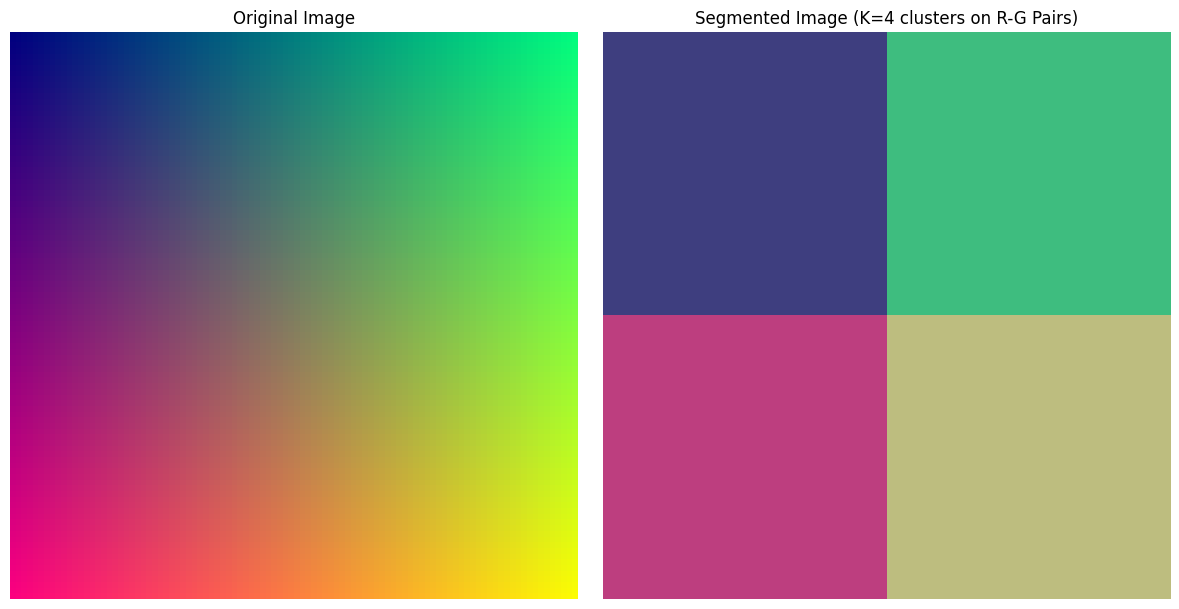

In [ ]:
# 1. Create a synthetic image with distinct color gradients (100x100 pixels, 3 channels)
height, width = 100, 100
image = np.zeros((height, width, 3))
for y in range(height):
    for x in range(width):
        # Fill Red and Green channels creating smooth spatial color transitions
        image[y, x, 0] = (y / height)       # Red
        image[y, x, 1] = (x / width)        # Green
        image[y, x, 2] = 0.5 - (x*y / (width*height)*0.5) # Blue

# 2. Extract features: Let's cluster based on (Red, Green) pixel pairs
pixel_pairs = image[:, :, :2].reshape(-1, 2)

# 3. Fit K-Means on the pixel pairs (K=4 color clusters)
k_colors = 4
k_means_img = KMeansScratch(k=k_colors, max_iters=50)
img_labels, img_centroids = k_means_img.fit(pixel_pairs)

# Reconstruct segmented image where each pixel gets its cluster centroid color
segmented_pixel_pairs = img_centroids[img_labels]
# Fill back the blue channel with constant 0.5 for simple visualization
segmented_image_flat = np.hstack([segmented_pixel_pairs, np.full((segmented_pixel_pairs.shape[0], 1), 0.5)])
segmented_image = segmented_image_flat.reshape(height, width, 3)

# 4. Plot the original and segmented images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(segmented_image)
axes[1].set_title(f'Segmented Image (K={k_colors} clusters on R-G Pairs)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Part 2: Hierarchical Clustering Algorithms from Scratch

We will implement:
1. **Agglomerative Clustering (Bottom-Up)** using Single Linkage.
2. **Divisive Clustering (Top-Down)** using K-Means (K=2) as the splitting mechanism.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class AgglomerativeClusteringScratch:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.labels_ = None

    def fit_predict(self, X):
        n_samples = X.shape[0]
        # Initially, each point is its own cluster
        clusters = {i: [i] for i in range(n_samples)}

        # Precompute pairwise distance matrix
        dist_matrix = np.linalg.norm(X[:, np.newaxis] - X, axis=2)
        np.fill_diagonal(dist_matrix, np.inf)

        while len(clusters) > self.n_clusters:
            min_dist = np.inf
            merge_pair = (None, None)

            # Find the two closest clusters using Single Linkage
            cluster_keys = list(clusters.keys())
            for i in range(len(cluster_keys)):
                for j in range(i + 1, len(cluster_keys)):
                    c1 = clusters[cluster_keys[i]]
                    c2 = clusters[cluster_keys[j]]

                    # Single Linkage: Min distance between any point in c1 and any point in c2
                    sub_matrix = dist_matrix[np.ix_(c1, c2)]
                    d = np.min(sub_matrix)

                    if d < min_dist:
                        min_dist = d
                        merge_pair = (cluster_keys[i], cluster_keys[j])

            # Merge clusters
            c_to_keep, c_to_remove = merge_pair
            clusters[c_to_keep].extend(clusters[c_to_remove])
            del clusters[c_to_remove]

        # Assign labels based on the final clusters
        self.labels_ = np.zeros(n_samples, dtype=int)
        for label, (cluster_idx, points) in enumerate(clusters.items()):
            for pt in points:
                self.labels_[pt] = label
        return self.labels_

In [ ]:
class DivisiveClusteringScratch:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.labels_ = None

    def _split_cluster(self, X, indices):
        # Use our 2-Way KMeans to split the cluster indices into two groups
        if len(indices) <= 1:
            return indices, []

        sub_X = X[indices]
        # Instantiate our custom KMeans scratch class with K=2
        kmeans = KMeansScratch(k=2, max_iters=20)
        sub_labels, _ = kmeans.fit(sub_X)

        group1 = [indices[i] for i in range(len(indices)) if sub_labels[i] == 0]
        group2 = [indices[i] for i in range(len(indices)) if sub_labels[i] == 1]
        return group1, group2

    def fit_predict(self, X):
        n_samples = X.shape[0]
        # Start with one giant cluster containing all indices
        clusters = [list(range(n_samples))]

        while len(clusters) < self.n_clusters:
            # Select the largest cluster to split
            cluster_sizes = [len(c) for c in clusters]
            largest_cluster_idx = np.argmax(cluster_sizes)
            cluster_to_split = clusters.pop(largest_cluster_idx)

            # Split it into two
            g1, g2 = self._split_cluster(X, cluster_to_split)
            clusters.append(g1)
            if len(g2) > 0:
                clusters.append(g2)

        # Map cluster assignments to labels
        self.labels_ = np.zeros(n_samples, dtype=int)
        for label, cluster in enumerate(clusters):
            for pt in cluster:
                self.labels_[pt] = label
        return self.labels_

### Run and Compare Hierarchical Clustering on the Datasets
We will downsample the datasets slightly where necessary to keep pairwise computations efficient for scratch implementations.

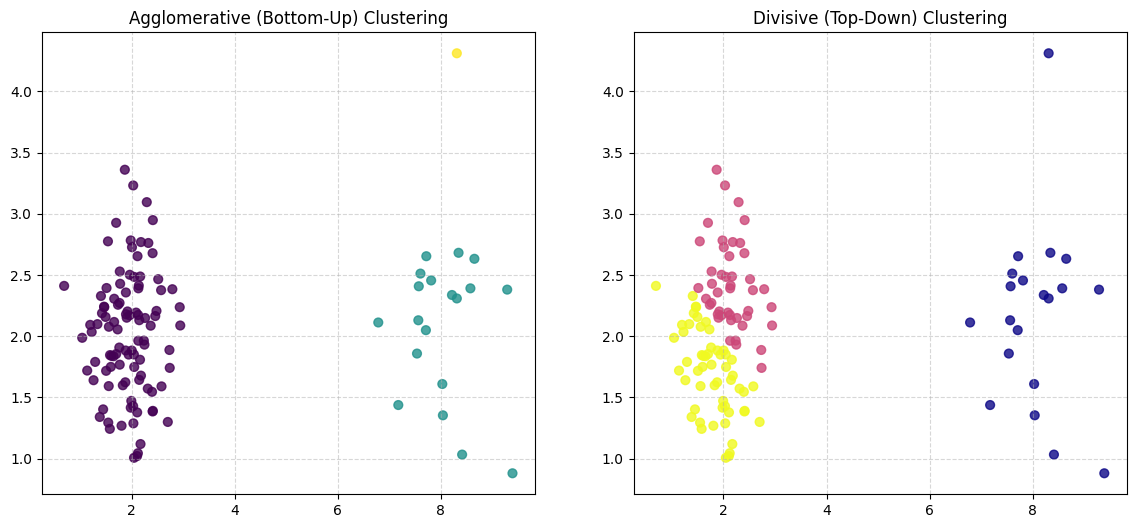

In [ ]:
# Downsample random data for faster computation of distance matrices
X_sample = X_no_outliers[:120]  # Take a subset of 120 points

# 1. Agglomerative (Bottom-Up)
agg = AgglomerativeClusteringScratch(n_clusters=3)
labels_agg = agg.fit_predict(X_sample)

# 2. Divisive (Top-Down)
div = DivisiveClusteringScratch(n_clusters=3)
labels_div = div.fit_predict(X_sample)

# Plotting results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_sample[:, 0], X_sample[:, 1], c=labels_agg, cmap='viridis', s=40, alpha=0.8)
axes[0].set_title('Agglomerative (Bottom-Up) Clustering')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(X_sample[:, 0], X_sample[:, 1], c=labels_div, cmap='plasma', s=40, alpha=0.8)
axes[1].set_title('Divisive (Top-Down) Clustering')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

### Part 2.b: Hierarchical Clustering on Random Data with Outliers

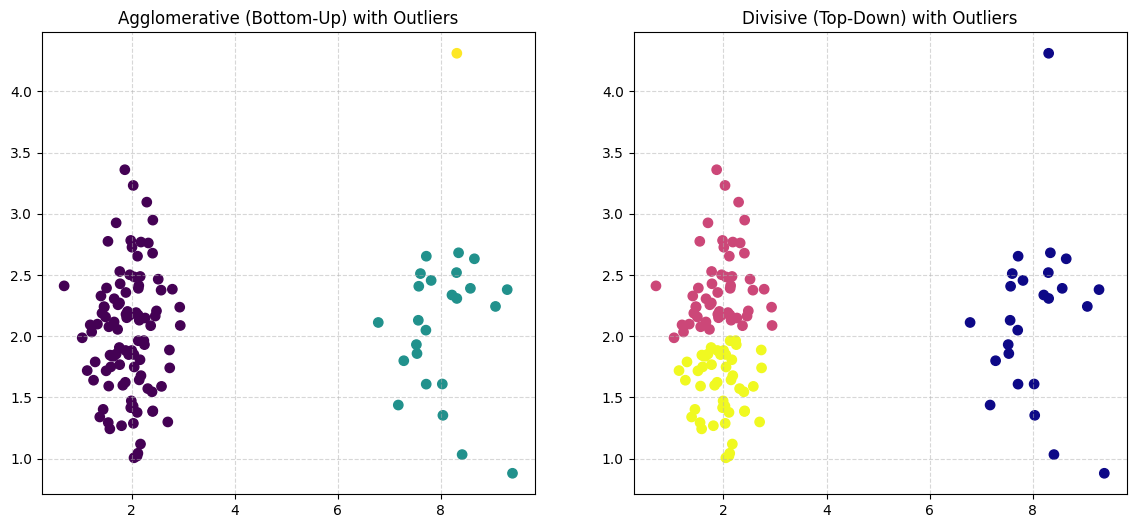

In [ ]:
# 1. Sample from our outlier dataset (using all points including the 5 outliers)
X_outlier_sample = X_with_outliers[:125]

# 2. Fit Agglomerative
agg_outliers = AgglomerativeClusteringScratch(n_clusters=3)
labels_agg_out = agg_outliers.fit_predict(X_outlier_sample)

# 3. Fit Divisive
div_outliers = DivisiveClusteringScratch(n_clusters=3)
labels_div_out = div_outliers.fit_predict(X_outlier_sample)

# Plotting results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_outlier_sample[:, 0], X_outlier_sample[:, 1], c=labels_agg_out, cmap='viridis', s=45)
axes[0].set_title('Agglomerative (Bottom-Up) with Outliers')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(X_outlier_sample[:, 0], X_outlier_sample[:, 1], c=labels_div_out, cmap='plasma', s=45)
axes[1].set_title('Divisive (Top-Down) with Outliers')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

### Part 2.c: Hierarchical Clustering on California Housing Spatial Tabular Data

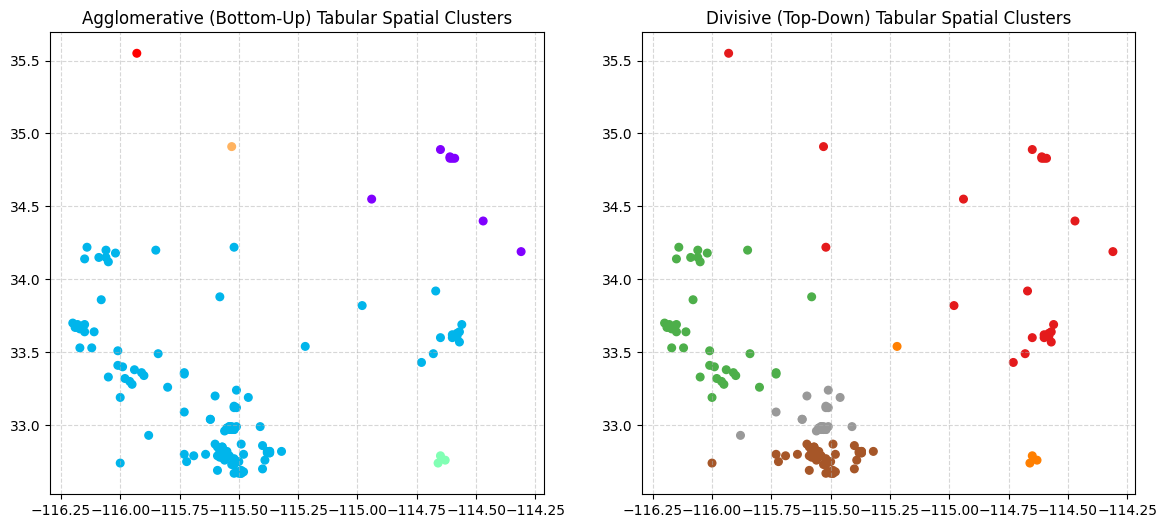

In [ ]:
# Downsample spatial scaled coordinates for hierarchical processing efficiency
X_tab_sample = X_scaled[:150]

# Fit Agglomerative
agg_tab = AgglomerativeClusteringScratch(n_clusters=5)
labels_agg_tab = agg_tab.fit_predict(X_tab_sample)

# Fit Divisive
div_tab = DivisiveClusteringScratch(n_clusters=5)
labels_div_tab = div_tab.fit_predict(X_tab_sample)

# Plot results side-by-side on original scale coordinates
X_orig_sample = (X_tab_sample * X_std) + X_mean

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_orig_sample[:, 0], X_orig_sample[:, 1], c=labels_agg_tab, cmap='rainbow', s=30)
axes[0].set_title('Agglomerative (Bottom-Up) Tabular Spatial Clusters')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(X_orig_sample[:, 0], X_orig_sample[:, 1], c=labels_div_tab, cmap='Set1', s=30)
axes[1].set_title('Divisive (Top-Down) Tabular Spatial Clusters')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

### Part 2.d: Hierarchical Clustering on Image Pixel Pairs (Color Segmentation)

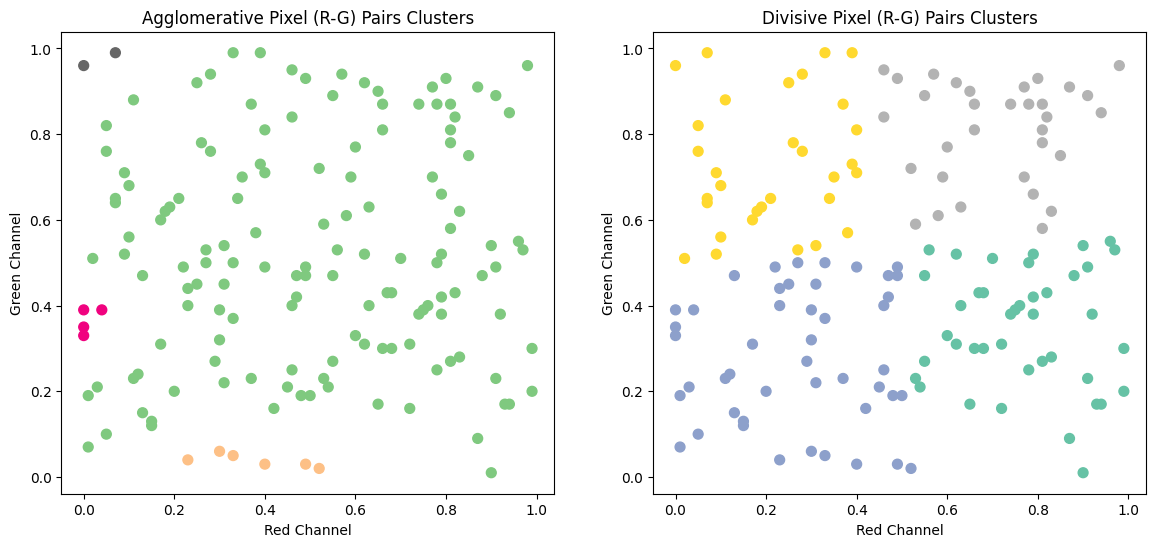

In [ ]:
# Downsample pixel pairs from the 100x100 grid (taking 150 stratified samples for demonstration)
np.random.seed(42)
sample_indices = np.random.choice(pixel_pairs.shape[0], 150, replace=False)
pixel_sample = pixel_pairs[sample_indices]

# Fit Agglomerative
agg_img = AgglomerativeClusteringScratch(n_clusters=4)
labels_agg_img = agg_img.fit_predict(pixel_sample)

# Fit Divisive
div_img = DivisiveClusteringScratch(n_clusters=4)
labels_div_img = div_img.fit_predict(pixel_sample)

# Plot the color clusters in (R, G) color space
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(pixel_sample[:, 0], pixel_sample[:, 1], c=labels_agg_img, cmap='Accent', s=50)
axes[0].set_title('Agglomerative Pixel (R-G) Pairs Clusters')
axes[0].set_xlabel('Red Channel')
axes[0].set_ylabel('Green Channel')

axes[1].scatter(pixel_sample[:, 0], pixel_sample[:, 1], c=labels_div_img, cmap='Set2', s=50)
axes[1].set_title('Divisive Pixel (R-G) Pairs Clusters')
axes[1].set_xlabel('Red Channel')
axes[1].set_ylabel('Green Channel')

plt.show()